We have now all the tools to compare SPT and CLASS efficiently

In [1]:
%load_ext autoreload
%autoreload 2
# Cell 1 in your Jupyter Notebook
import sys
import os

# Point Python to the main icetmosphere folder
sys.path.append(os.path.abspath('..'))

In [2]:
from atm_tools import alpha_specific_function
from class_and_spt_emission import compute_T_RJ_ice2, compute_T_RJ_ice_CLASS1, compute_depolarization_factor
from scipy import constants
import pycraf
from astropy import units as u

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Update global parameters for presentation visibility
plt.rcParams.update({
    'font.size': 18,              # General font size for text
    'axes.labelsize': 20,         # Size of X and Y axis labels
    'axes.titlesize': 24,         # Size of the graph title
    'xtick.labelsize': 16,        # Size of the numbers on the X axis
    'ytick.labelsize': 16,        # Size of the numbers on the Y axis
    'legend.fontsize': 16,        # Size of the legend text
    'lines.linewidth': 3,       # Thicker lines for the plotted data
})

In [4]:
altitudes = np.linspace(1, 10000, 500) #m
altitudes = altitudes +4999 #m

altitudes_km = altitudes * u.m       # maintenant c'est une Quantity en m
altitudes_km = altitudes_km.to(u.km) # conversion en km
Temperature = pycraf.atm.profile_standard(altitudes_km)[0].value #en K
Pressure = pycraf.atm.profile_standard(altitudes_km)[1].value #en hPa
rho_water = pycraf.atm.profile_standard(altitudes_km)[2].value #en g/m3
P_water = pycraf.atm.profile_standard(altitudes_km)[3].value #en hPa
dz = np.diff(altitudes) # Shape: (len(altitudes)-1,)
frequency_ghz = np.array([90, 150, 188, 220]) # GHz
frequency = frequency_ghz * 1e9 # Hz

In [7]:
pi = constants.pi 
c = constants.c
rho_ice = 917 #kg/m^3

elevation = 45 #degrees
IWP = 1e-3 #kg/m2

layer_bottom = 6000  # Bottom of the ice cloud layer in meters (example)
layer_top = 7000     # Top of the ice cloud layer in meters (example)
cloud_thickness = layer_top - layer_bottom # Thickness of the ice cloud layer in meters

r_eq = np.arange(1e-6, 200e-6, 5e-6)

# 3. Calculate d(IWP)/dz (which is the Ice Water Content)
# For a uniform cloud, it is just Total IWP / thickness
IWC_constant = IWP / cloud_thickness # kg/m^3

# Create the IWC profile (0 everywhere except in the cloud)
IWC_profile = np.where((altitudes >= layer_bottom) & (altitudes <= layer_top), IWC_constant, 0.0)
# Shape of IWC_profile is (Nz,)

# 4. Compute Volume of the crystals for all radii
V = (4.0 / 3.0) * np.pi * r_eq**3 # Shape: (Na,)

# 5. Compute the ice density n(z, r_eq) using Broadcasting
# We use [:, None] to make IWC a column (Nz, 1) 
# We use [None, :] to make V a row (1, Na)
# The result is a 2D grid of shape (Nz, Na)
n = IWC_profile[:, None] / (rho_ice * V[None, :])

In [8]:
I_RJ_SPT = compute_T_RJ_ice2(frequency, altitudes, Temperature, Pressure, P_water, elevation, n, r_eq, aspect_ratio=1.0, process='scattering', stokes_param='I') #Shape (Nf, Na)
I_RJ_CLASS1 = compute_T_RJ_ice_CLASS1(frequency, altitudes, Temperature, Pressure, P_water, elevation, n, r_eq, aspect_ratio=1.0, stokes_param='I') #Shape (Nf, Na)

In [9]:
Q_RJ_SPT = compute_T_RJ_ice2(frequency, altitudes, Temperature, Pressure, P_water, elevation, n, r_eq, aspect_ratio=1.0, process='scattering', stokes_param='Q') #Shape (Nf, Na)
Q_RJ_CLASS1 = compute_T_RJ_ice_CLASS1(frequency, altitudes, Temperature, Pressure, P_water, elevation, n, r_eq, aspect_ratio=1.0, stokes_param='Q') #Shape (Nf, Na)

In [8]:
print("SPT Emission (I_RJ_SPT) shape:", I_RJ_SPT.shape)
print("CLASS1 Emission (I_RJ_CLASS1) shape:", I_RJ_CLASS1.shape)

SPT Emission (I_RJ_SPT) shape: (4, 40)
CLASS1 Emission (I_RJ_CLASS1) shape: (4, 40)


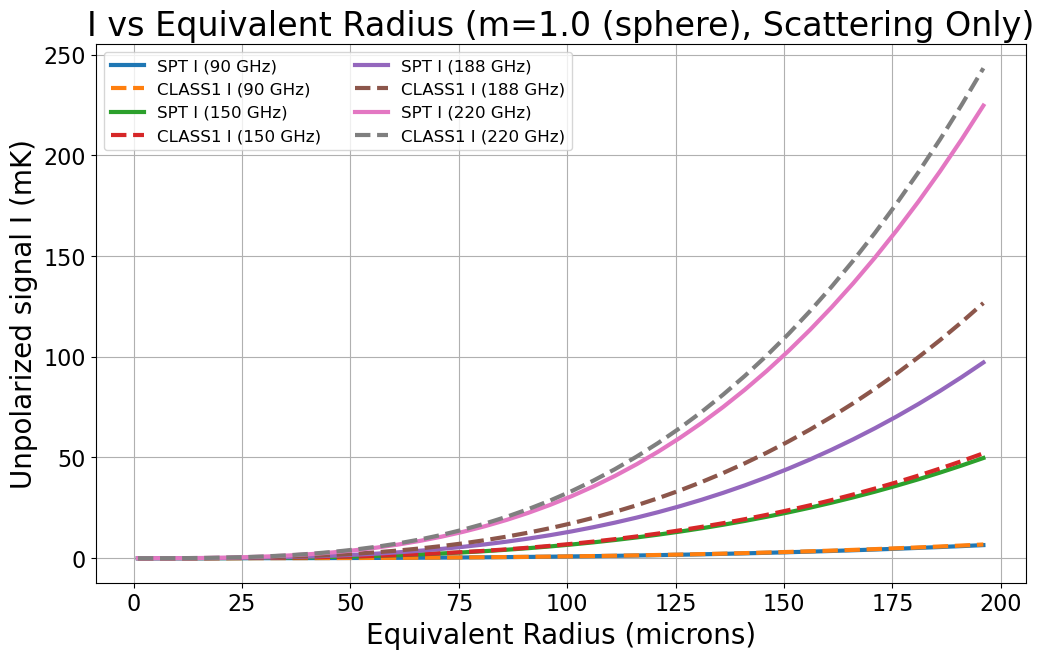

In [10]:
# Plot I for all frequencies as a function of equivalent radius
plt.figure(figsize=(12, 7))
for fi, fghz in enumerate(frequency_ghz):
    plt.plot(r_eq * 1e6, I_RJ_SPT[fi, :] * 1e3, label=f'SPT I ({fghz} GHz)')
    plt.plot(r_eq * 1e6, I_RJ_CLASS1[fi, :] * 1e3, linestyle='--', label=f'CLASS1 I ({fghz} GHz)')
plt.xlabel('Equivalent Radius (microns)')
plt.ylabel('Unpolarized signal I (mK)')
plt.title('I vs Equivalent Radius (m=1.0 (sphere), Scattering Only)')
plt.legend(ncol=2, fontsize=12)
plt.grid()
plt.show()

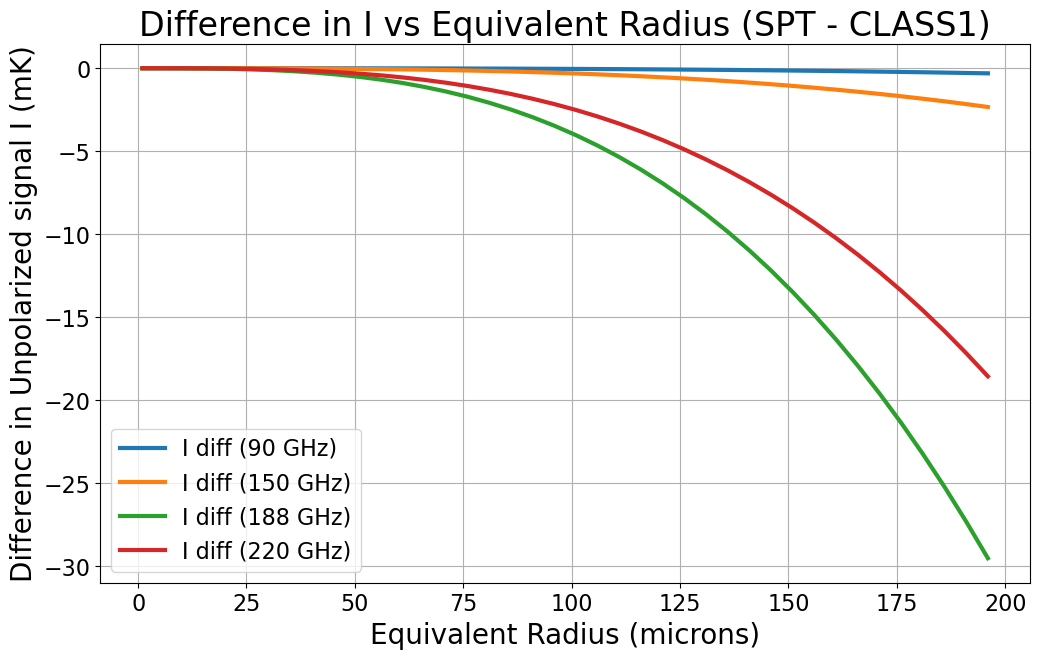

In [11]:
# Plot I difference (SPT - CLASS1) for all frequencies
plt.figure(figsize=(12, 7))
for fi, fghz in enumerate(frequency_ghz):
    plt.plot(r_eq * 1e6, (I_RJ_SPT[fi, :] - I_RJ_CLASS1[fi, :]) * 1e3, label=f'I diff ({fghz} GHz)')
plt.xlabel('Equivalent Radius (microns)')
plt.ylabel('Difference in Unpolarized signal I (mK)')
plt.title('Difference in I vs Equivalent Radius (SPT - CLASS1)')
plt.legend()
plt.grid()
plt.show()

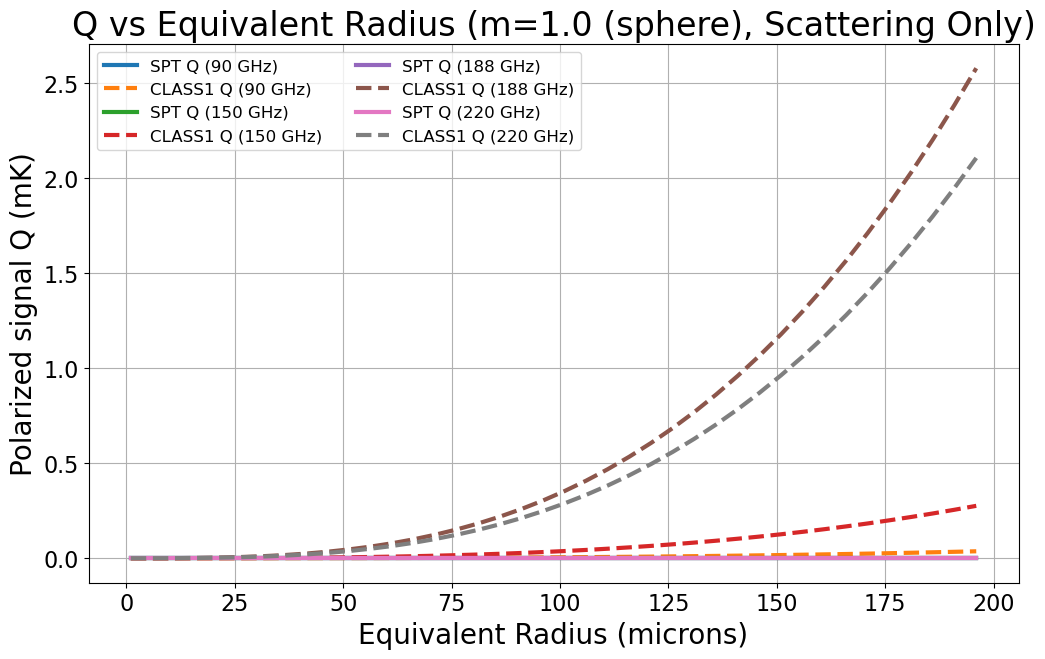

In [12]:
# Plot Q for all frequencies as a function of equivalent radius
plt.figure(figsize=(12, 7))
for fi, fghz in enumerate(frequency_ghz):
    plt.plot(r_eq * 1e6, Q_RJ_SPT[fi, :] * 1e3, label=f'SPT Q ({fghz} GHz)')
    plt.plot(r_eq * 1e6, Q_RJ_CLASS1[fi, :] * 1e3, linestyle='--', label=f'CLASS1 Q ({fghz} GHz)')
plt.xlabel('Equivalent Radius (microns)')
plt.ylabel('Polarized signal Q (mK)')
plt.title('Q vs Equivalent Radius (m=1.0 (sphere), Scattering Only)')
plt.legend(ncol=2, fontsize=12)
plt.grid()
plt.show()

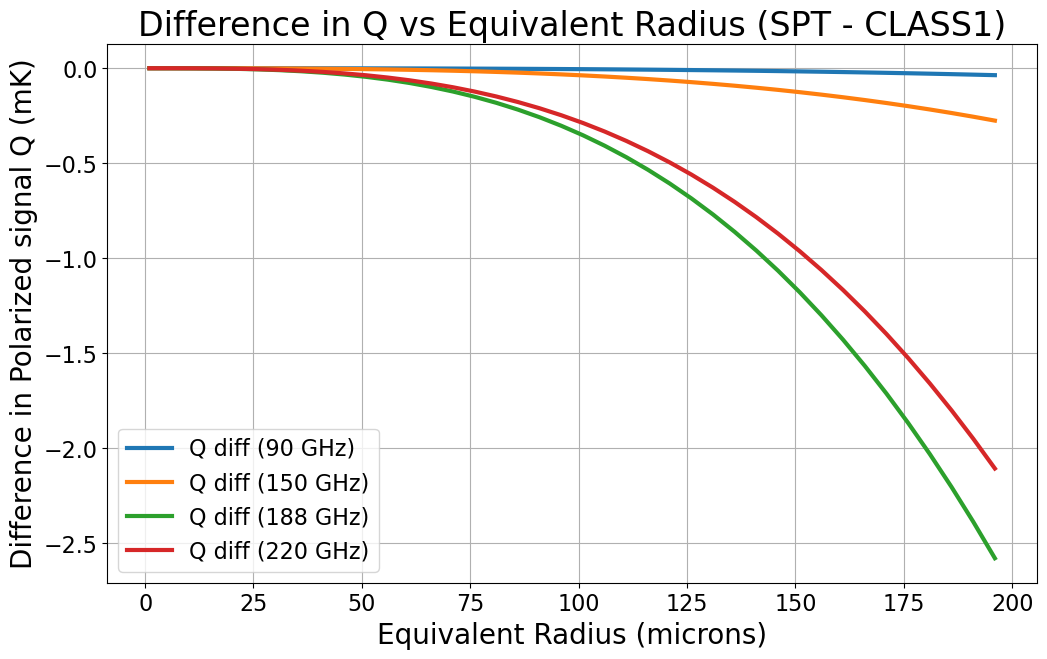

In [13]:
# Plot Q difference (SPT - CLASS1) for all frequencies
plt.figure(figsize=(12, 7))
for fi, fghz in enumerate(frequency_ghz):
    plt.plot(r_eq * 1e6, (Q_RJ_SPT[fi, :] - Q_RJ_CLASS1[fi, :]) * 1e3, label=f'Q diff ({fghz} GHz)')
plt.xlabel('Equivalent Radius (microns)')
plt.ylabel('Difference in Polarized signal Q (mK)')
plt.title('Difference in Q vs Equivalent Radius (SPT - CLASS1)')
plt.legend()
plt.grid()
plt.show()

Let's do it with a plate

In [14]:
I_RJ_SPT = compute_T_RJ_ice2(frequency, altitudes, Temperature, Pressure, P_water, elevation, n, r_eq, aspect_ratio=0.5, process='scattering', stokes_param='I') #Shape (Nf, Na)
I_RJ_CLASS1 = compute_T_RJ_ice_CLASS1(frequency, altitudes, Temperature, Pressure, P_water, elevation, n, r_eq, aspect_ratio=0.5, stokes_param='I') #Shape (Nf, Na)

Q_RJ_SPT = compute_T_RJ_ice2(frequency, altitudes, Temperature, Pressure, P_water, elevation, n, r_eq, aspect_ratio=0.5, process='scattering', stokes_param='Q') #Shape (Nf, Na)
Q_RJ_CLASS1 = compute_T_RJ_ice_CLASS1(frequency, altitudes, Temperature, Pressure, P_water, elevation, n, r_eq, aspect_ratio=0.5, stokes_param='Q') #Shape (Nf, Na)

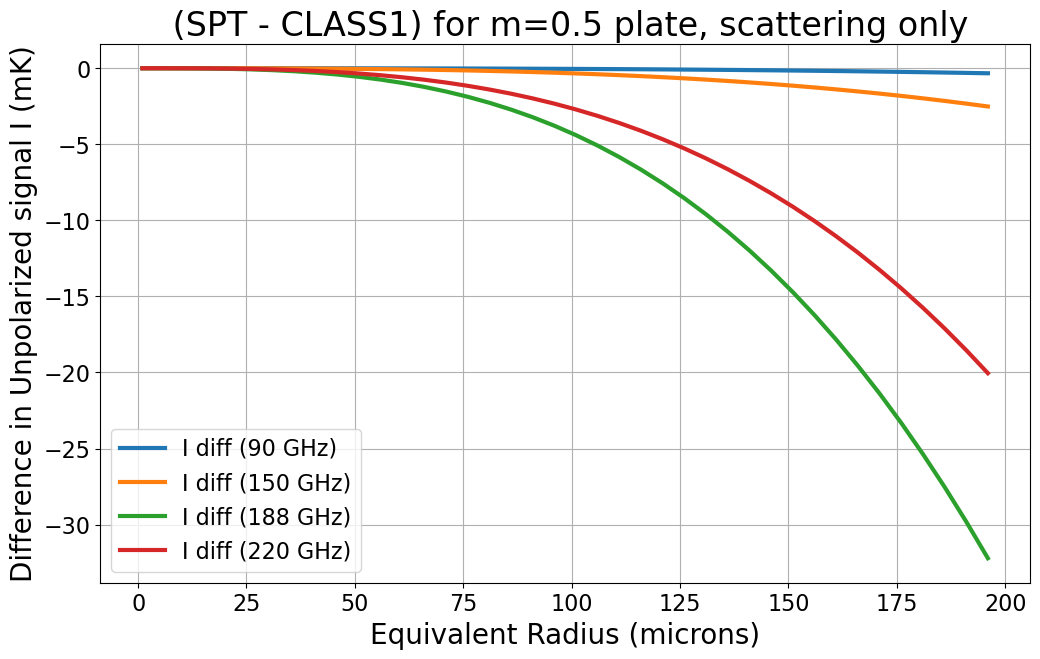

In [15]:
# Plot I difference (SPT - CLASS1) for all frequencies
plt.figure(figsize=(12, 7))
for fi, fghz in enumerate(frequency_ghz):
    plt.plot(r_eq * 1e6, (I_RJ_SPT[fi, :] - I_RJ_CLASS1[fi, :]) * 1e3, label=f'I diff ({fghz} GHz)')
plt.xlabel('Equivalent Radius (microns)')
plt.ylabel('Difference in Unpolarized signal I (mK)')
plt.title(' (SPT - CLASS1) for m=0.5 plate, scattering only')
plt.legend()
plt.grid()
plt.show()

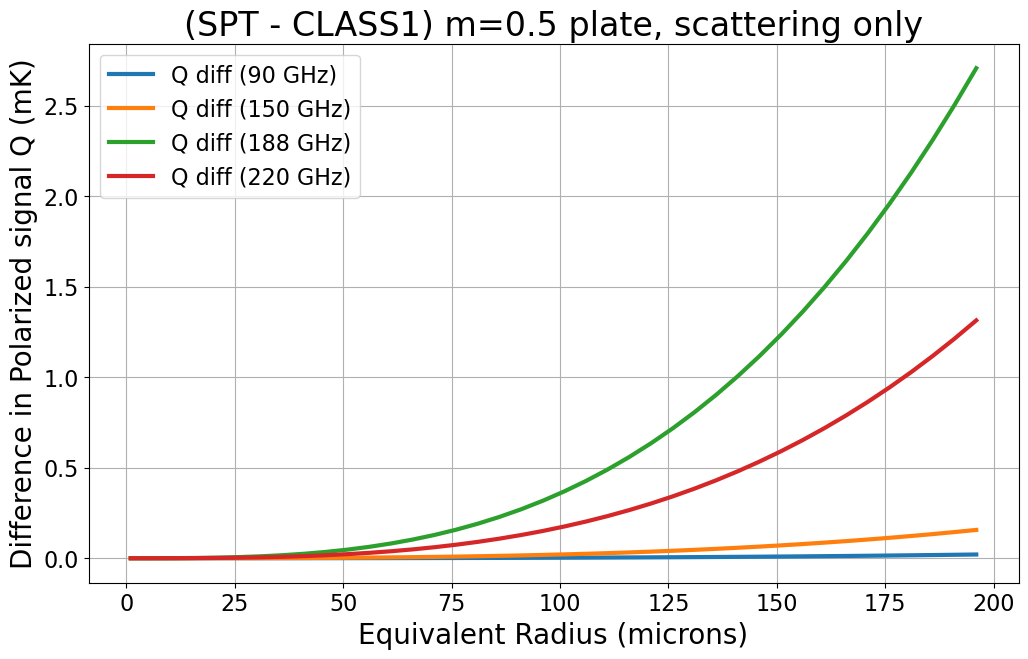

In [16]:
# Plot Q difference (SPT - CLASS1) for all frequencies
plt.figure(figsize=(12, 7))
for fi, fghz in enumerate(frequency_ghz):
    plt.plot(r_eq * 1e6, (Q_RJ_SPT[fi, :] - Q_RJ_CLASS1[fi, :]) * 1e3, label=f'Q diff ({fghz} GHz)')
plt.xlabel('Equivalent Radius (microns)')
plt.ylabel('Difference in Polarized signal Q (mK)')
plt.title('(SPT - CLASS1) m=0.5 plate, scattering only')
plt.legend()
plt.grid()
plt.show()

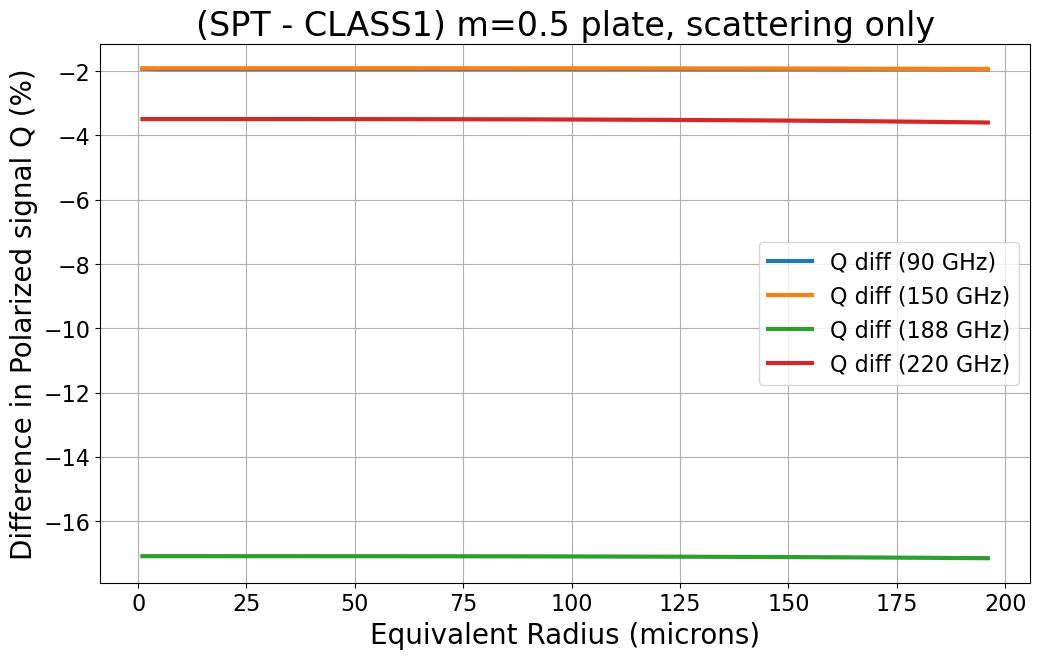

In [17]:
# Plot Q difference (SPT - CLASS1) for all frequencies
plt.figure(figsize=(12, 7))
for fi, fghz in enumerate(frequency_ghz):
    plt.plot(r_eq * 1e6, (Q_RJ_SPT[fi, :] - Q_RJ_CLASS1[fi, :]) / Q_RJ_SPT[fi,:] * 100, label=f'Q diff ({fghz} GHz)')
plt.xlabel('Equivalent Radius (microns)')
plt.ylabel('Difference in Polarized signal Q (%)')
plt.title('(SPT - CLASS1) m=0.5 plate, scattering only')
plt.legend()
plt.grid()
plt.show()

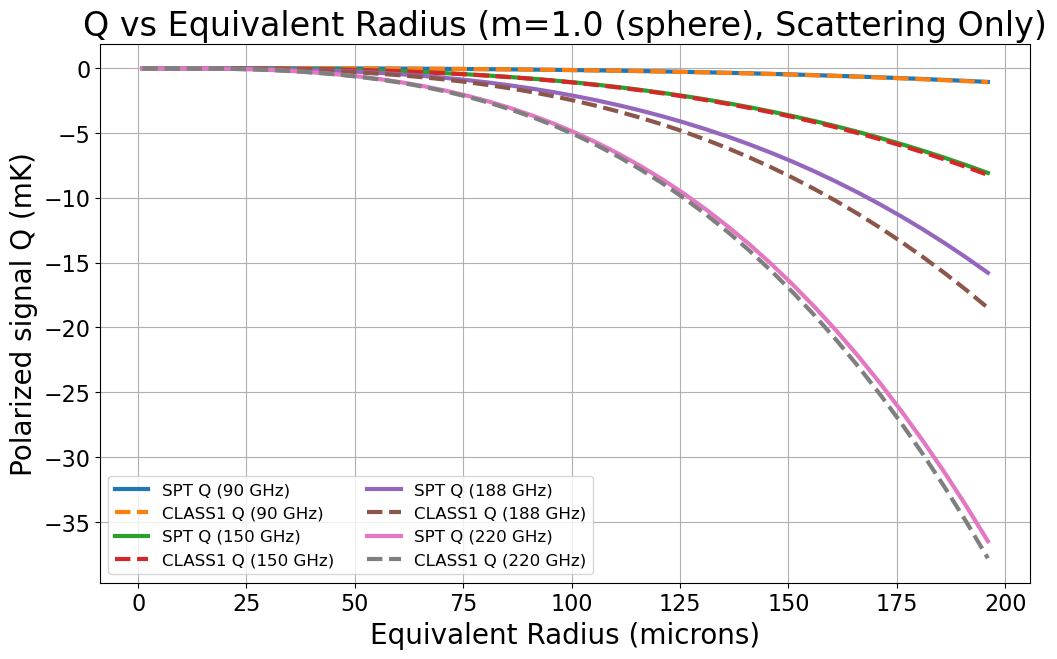

In [18]:
# Plot Q for all frequencies as a function of equivalent radius
plt.figure(figsize=(12, 7))
for fi, fghz in enumerate(frequency_ghz):
    plt.plot(r_eq * 1e6, Q_RJ_SPT[fi, :] * 1e3, label=f'SPT Q ({fghz} GHz)')
    plt.plot(r_eq * 1e6, Q_RJ_CLASS1[fi, :] * 1e3, linestyle='--', label=f'CLASS1 Q ({fghz} GHz)')
plt.xlabel('Equivalent Radius (microns)')
plt.ylabel('Polarized signal Q (mK)')
plt.title('Q vs Equivalent Radius (m=1.0 (sphere), Scattering Only)')
plt.legend(ncol=2, fontsize=12)
plt.grid()
plt.show()

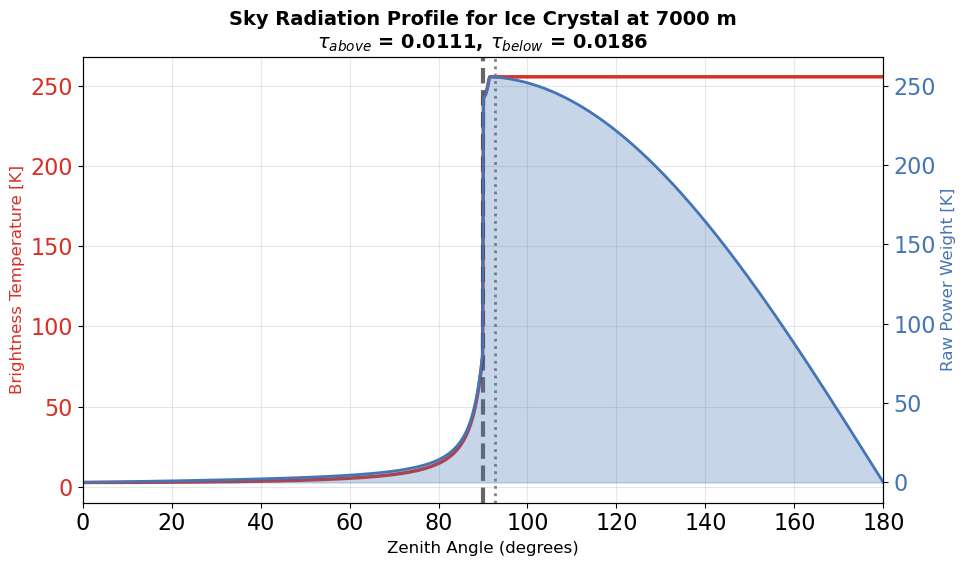

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from astropy import units as u
import pycraf.atm

# =========================================================
# 1. ATMOSPHERIC SETUP (Your Code)
# =========================================================
altitudes = np.linspace(1, 10000, 500) # m
altitudes = altitudes + 4999 # m (Range: 5000m to 14999m)

altitudes_km = altitudes * u.m
altitudes_km = altitudes_km.to(u.km) 

# pycraf Standard Profile
Temperature = pycraf.atm.profile_standard(altitudes_km)[0].value # K
Pressure = pycraf.atm.profile_standard(altitudes_km)[1].value # hPa
rho_water = pycraf.atm.profile_standard(altitudes_km)[2].value # g/m3
P_water = pycraf.atm.profile_standard(altitudes_km)[3].value # hPa

dz = np.diff(altitudes)
z_layers = (altitudes[:-1] + altitudes[1:]) / 2.0
T_mid = (Temperature[:-1] + Temperature[1:]) / 2.0

# =========================================================
# 2. OPTICAL DEPTH CALCULATION
# =========================================================
# Choose a test frequency (e.g., 150 GHz)
frequency = np.array([150e9]) 

# Call your specific alpha function (Returns shape: Nz, Nf)
alpha_atm = alpha_specific_function(altitudes, frequency, Temperature, Pressure, P_water)

# Midpoint alphas and layer optical depths
alpha_atm_mid = (alpha_atm[:-1, 0] + alpha_atm[1:, 0]) / 2.0
d_tau_atm = alpha_atm_mid * dz 

# Cumulative optical depths
tau_below_atm = np.insert(np.cumsum(d_tau_atm), 0, 0)[:-1]
tau_above_atm = np.zeros_like(d_tau_atm)
tau_above_atm[:-1] = np.cumsum(d_tau_atm[1:][::-1])[::-1]

# =========================================================
# 3. SELECT PARTICLE ALTITUDE
# =========================================================
target_altitude = 7000.0 # meters
target_idx = np.argmin(np.abs(z_layers - target_altitude))

z_part = z_layers[target_idx]
T_part = T_mid[target_idx]
T_ground = Temperature[0] # Ground is at 5000m in this profile
tau_above = tau_above_atm[target_idx]
tau_below = tau_below_atm[target_idx]

# =========================================================
# 4. CALCULATE 1D SKY PROFILE
# =========================================================
theta = np.linspace(0, np.pi, 1000)
R_e = 6371e3

# Geometric Boundaries
theta_h = np.sqrt(2 * z_part / R_e)
bound_sky = np.pi / 2
bound_limb = (np.pi / 2) + theta_h

# A. Sky Regime (Theta < 90)
theta_deg = np.clip(np.degrees(theta), 0, 90.0)
m_sky = 1.0 / (np.cos(theta) + 0.50572 * (96.07995 - theta_deg)**(-1.6364))
T_sky = T_part * (1.0 - np.exp(-tau_above * m_sky))

# B. Limb Regime (90 <= Theta <= 90 + theta_h)
z_min = (R_e + z_part) * np.sin(theta) - R_e
T_limb = np.interp(z_min, altitudes, Temperature)

# C. Ground Regime (Theta > 90 + theta_h)
m_gnd = 1.0 / np.maximum(np.cos(np.pi - theta), 0.01)
T_gnd_att = T_ground #* np.exp(-tau_below * m_gnd) + T_part * (1.0 - np.exp(-tau_below * m_gnd))

# Stitch together
conditions = [theta < bound_sky, (theta >= bound_sky) & (theta <= bound_limb), theta > bound_limb]
T_in = np.select(conditions, [T_sky, T_limb, T_gnd_att])

# =========================================================
# 5. PLOTTING
# =========================================================
theta_deg_plot = np.degrees(theta)

fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot 1: Brightness Temperature (Left Axis)
color1 = '#d73027'
ax1.plot(theta_deg_plot, T_in, color=color1, linewidth=2.5, label='Incoming T_in')
ax1.set_xlabel('Zenith Angle (degrees)', fontsize=12)
ax1.set_ylabel('Brightness Temperature [K]', color=color1, fontsize=12)
ax1.tick_params(axis='y', labelcolor=color1)
ax1.set_xlim(0, 180)

# Plot 2: Integrand (Right Axis)
ax2 = ax1.twinx()
integrand = T_in * np.sin(theta)
color2 = '#4575b4'
ax2.fill_between(theta_deg_plot, 0, integrand, color=color2, alpha=0.3, label='Raw Integrand (T_in * sinθ)')
ax2.plot(theta_deg_plot, integrand, color=color2, linewidth=2)
ax2.set_ylabel('Raw Power Weight [K]', color=color2, fontsize=12)
ax2.tick_params(axis='y', labelcolor=color2)

# Geometric Markers
ax1.axvline(90, color='black', linestyle='--', alpha=0.6, label='True Horizontal (90°)')
ax1.axvline(90 + np.degrees(theta_h), color='gray', linestyle=':', linewidth=2, label='Geometric Horizon Limb')

# Formatting
plt.title(f'Sky Radiation Profile for Ice Crystal at {target_altitude:.0f} m\n$\\tau_{{above}}$ = {tau_above:.4f}, $\\tau_{{below}}$ = {tau_below:.4f}', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

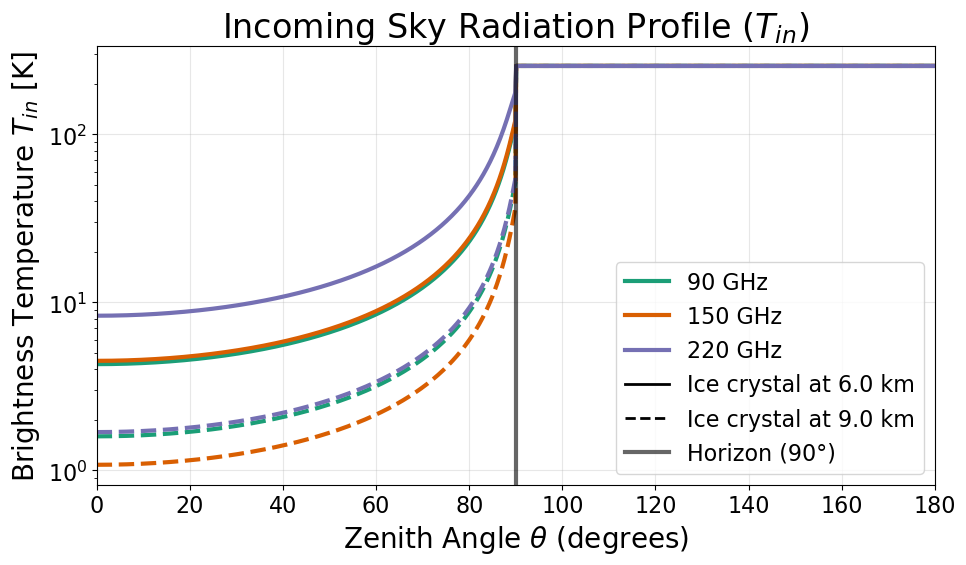

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from astropy import units as u
import pycraf.atm

# =========================================================
# 1. ATMOSPHERIC SETUP
# =========================================================
altitudes = np.linspace(1, 15001, 500) # m
altitudes = altitudes + 4999 # m (Range: 5000m to 14999m)

altitudes_km = altitudes * u.m
altitudes_km = altitudes_km.to(u.km) 

# pycraf Standard Profile
Temperature = pycraf.atm.profile_standard(altitudes_km)[0].value # K
Pressure = pycraf.atm.profile_standard(altitudes_km)[1].value # hPa
rho_water = pycraf.atm.profile_standard(altitudes_km)[2].value # g/m3
P_water = pycraf.atm.profile_standard(altitudes_km)[3].value # hPa

dz = np.diff(altitudes)
z_layers = (altitudes[:-1] + altitudes[1:]) / 2.0
T_mid = (Temperature[:-1] + Temperature[1:]) / 2.0
T_ground = Temperature[0] # Ground is at 5000m in this profile

# =========================================================
# 2. DEFINING ITERATION ARRAYS
# =========================================================
frequencies = np.array([90e9, 150e9, 220e9])
freq_labels = ['90 GHz', '150 GHz', '220 GHz']
freq_colors = ['#1b9e77', '#d95f02', '#7570b3'] 

target_altitudes = [6000.0, 9000.0]  
alt_styles = ['-', '--']             

# Global Angular Setup
theta = np.linspace(0, np.pi, 1000)
theta_deg = np.clip(np.degrees(theta), 0, 90.0)

# =========================================================
# 3. PLOTTING SETUP & CALCULATIONS
# =========================================================
fig, ax = plt.subplots(figsize=(10, 6)) 

for i, freq in enumerate(frequencies):
    
    # A. Optical Depth for this specific frequency
    alpha_atm = alpha_specific_function(altitudes, np.array([freq]), Temperature, Pressure, P_water)
    alpha_atm_mid = (alpha_atm[:-1, 0] + alpha_atm[1:, 0]) / 2.0
    d_tau_atm = alpha_atm_mid * dz 
    
    tau_below_atm = np.insert(np.cumsum(d_tau_atm), 0, 0)[:-1]
    tau_above_atm = np.zeros_like(d_tau_atm)
    tau_above_atm[:-1] = np.cumsum(d_tau_atm[1:][::-1])[::-1]
    
    # B. Iterate over target altitudes
    for j, target_altitude in enumerate(target_altitudes):
        target_idx = np.argmin(np.abs(z_layers - target_altitude))
        
        T_part = T_mid[target_idx]
        tau_above = tau_above_atm[target_idx]
        
        # 1. Sky Regime (Theta <= 90 degrees)
        m_sky = 1.0 / (np.cos(theta) + 0.50572 * (96.07995 - theta_deg)**(-1.6364))
        T_sky = T_part * (1.0 - np.exp(-tau_above * m_sky))
        
        # 2. Stitch together (No Earth Curvature: if theta > 90, T = T_ground)
        T_in = np.where(theta <= np.pi / 2, T_sky, T_ground)
        
        # Plot without default labels to keep the legend clean
        ax.plot(np.degrees(theta), T_in, 
                color=freq_colors[i], 
                linestyle=alt_styles[j],
                linewidth=3)

# =========================================================
# 4. FORMATTING & CUSTOM LEGEND
# =========================================================
ax.axvline(90, color='black', alpha=0.6)

ax.set_title('Incoming Sky Radiation Profile ($T_{in}$)')
ax.set_xlabel('Zenith Angle $\\theta$ (degrees)')
ax.set_ylabel('Brightness Temperature $T_{in}$ [K]')
ax.set_xlim(0, 180)
ax.set_yscale('log')
ax.grid(True, alpha=0.3)

# --- Building the Custom Legend ---
custom_lines = []
custom_labels = []

# 1. Frequency Legend Entries (Colors)
for i in range(len(frequencies)):
    custom_lines.append(Line2D([0], [0], color=freq_colors[i], lw=3))
    custom_labels.append(freq_labels[i])

# 2. Altitude Legend Entries (Linestyles, drawn in black)
for j in range(len(target_altitudes)):
    custom_lines.append(Line2D([0], [0], color='black', linestyle=alt_styles[j], lw=2))
    custom_labels.append(f'Ice crystal at {target_altitudes[j]/1000:.1f} km')

# 3. Horizontal Line Entry
custom_lines.append(Line2D([0], [0], color='black', alpha=0.6))
custom_labels.append('Horizon (90°)')

ax.legend(custom_lines, custom_labels, loc='lower right', ncol=1)

fig.tight_layout()
plt.show()

Let's redo figure 3 from the CLASS paper

In [7]:
import numpy as np
from scipy import constants
from astropy import units as u
import pycraf.atm

# =========================================================
# 1. ATMOSPHERIC PROFILE SETUP
# =========================================================
# Base of Cerro Toco is ~5200m ASL. We model from 5000m to 14999m.
altitudes = np.linspace(1, 10000, 500) # m
altitudes = altitudes + 4999 # m 

altitudes_km = altitudes * u.m       
altitudes_km = altitudes_km.to(u.km) 

# Fetch standard profiles
Temperature = pycraf.atm.profile_standard(altitudes_km)[0].value # K
Pressure = pycraf.atm.profile_standard(altitudes_km)[1].value # hPa
rho_water = pycraf.atm.profile_standard(altitudes_km)[2].value # g/m^3
P_water = pycraf.atm.profile_standard(altitudes_km)[3].value # hPa

dz = np.diff(altitudes) # Shape: (Nz-1,)

# =========================================================
# 2. PWV SCALING (Target = 2.0 mm)
# =========================================================
# 1 mm of PWV is exactly 1 kg/m^2 of water in the vertical column.
# rho_water is in g/m^3. Integrating rho_water * dz gives g/m^2.
# We divide by 1000 to get kg/m^2 (which is mm of PWV).
current_zenith_pwv_mm = np.sum(rho_water[:-1] * dz) / 1000.0

# Scale the water vapor profiles to exactly match the 2.0 mm Zenith PWV
# (The RT engine's airmass will naturally convert this to the slant path)
target_pwv_mm = 2.0 
scale_factor = target_pwv_mm / current_zenith_pwv_mm

P_water = P_water * scale_factor
rho_water = rho_water * scale_factor

print(f"Original Zenith PWV: {current_zenith_pwv_mm:.2f} mm")
print(f"Scaled Zenith PWV: {np.sum(rho_water[:-1] * dz) / 1000.0:.2f} mm")

# =========================================================
# 3. INSTRUMENT & ICE PARAMETERS
# =========================================================
frequency_ghz = np.array([40, 90, 150, 220]) # GHz
frequency = frequency_ghz * 1e9 # Hz

pi = constants.pi 
c = constants.c
rho_ice = 917 # kg/m^3

elevation = 45.0 # degrees

# Target Zenith IWP = 10 g/m^2 (from Figure 3 caption)
IWP_zenith = 10e-3 # kg/m^2 

# Particle size (Diameter = 100 um -> r_eq = 50 um)
r_eq = np.array([50e-6]) # meters
V = (4.0 / 3.0) * np.pi * r_eq**3 # Shape: (Na,)

# =========================================================
# 4. CLOUD LAYER SETUP (Both Cases)
# =========================================================
# Case 1: Cloud at 0.5 km above ground (~5700m ASL)
layer_bottom_1 = 5600.0  
layer_top_1 = 5800.0     
thickness_1 = layer_top_1 - layer_bottom_1 
IWC_constant_1 = IWP_zenith / thickness_1 
IWC_profile_1 = np.where((altitudes >= layer_bottom_1) & (altitudes <= layer_top_1), IWC_constant_1, 0.0)
n_1 = IWC_profile_1[:, None] / (rho_ice * V[None, :])

# Case 2: Cloud at 5.0 km above ground (~10200m ASL)
layer_bottom_2 = 10100.0  
layer_top_2 = 10300.0     
thickness_2 = layer_top_2 - layer_bottom_2 
IWC_constant_2 = IWP_zenith / thickness_2 
IWC_profile_2 = np.where((altitudes >= layer_bottom_2) & (altitudes <= layer_top_2), IWC_constant_2, 0.0)
n_2 = IWC_profile_2[:, None] / (rho_ice * V[None, :])

Original Zenith PWV: 1.23 mm
Scaled Zenith PWV: 2.00 mm


In [8]:
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# 1. SETUP SHAPE ARRAY
# =========================================================
# Create a geometric space for aspect ratio from 0.05 (extreme prolate/needles) 
# to 20.0 (extreme oblate/plates)
aspect_ratios = np.geomspace(0.1, 20.0, 200)

# Convert to depolarization factors using your existing function
delta_z_array = compute_depolarization_factor(aspect_ratios)

# Sort the arrays by delta_z so the plot lines draw smoothly from left to right
sort_idx = np.argsort(delta_z_array)
delta_z_array = delta_z_array[sort_idx]
aspect_ratios = aspect_ratios[sort_idx]

# =========================================================
# 2. INITIALIZE STORAGE MATRICES
# =========================================================
N_freq = len(frequency)
N_shapes = len(aspect_ratios)

# Cloud 1 (0.5 km)
I_out_1 = np.zeros((N_freq, N_shapes))
Q_out_1 = np.zeros((N_freq, N_shapes))

# Cloud 2 (5.0 km)
I_out_2 = np.zeros((N_freq, N_shapes))
Q_out_2 = np.zeros((N_freq, N_shapes))

# =========================================================
# 3. FULL RADIATIVE TRANSFER LOOP
# =========================================================
print("Running CLASS VRT simulations...")

for i, m_val in enumerate(aspect_ratios):
    
    # --- Cloud 1 (0.5 km) ---
    I_1 = compute_T_RJ_ice_CLASS1(frequency, altitudes, Temperature, Pressure, P_water, elevation, n_1, r_eq, aspect_ratio=m_val, stokes_param='I')
    Q_1 = compute_T_RJ_ice_CLASS1(frequency, altitudes, Temperature, Pressure, P_water, elevation, n_1, r_eq, aspect_ratio=m_val, stokes_param='Q')
    
    # Flatten drops the radius dimension -> shape (N_freq,)
    I_out_1[:, i] = I_1.flatten()
    Q_out_1[:, i] = Q_1.flatten()
    
    # --- Cloud 2 (5.0 km) ---
    I_2 = compute_T_RJ_ice_CLASS1(frequency, altitudes, Temperature, Pressure, P_water, elevation, n_2, r_eq, aspect_ratio=m_val, stokes_param='I')
    Q_2 = compute_T_RJ_ice_CLASS1(frequency, altitudes, Temperature, Pressure, P_water, elevation, n_2, r_eq, aspect_ratio=m_val, stokes_param='Q')
    
    I_out_2[:, i] = I_2.flatten()
    Q_out_2[:, i] = Q_2.flatten()

print("Simulation complete.")



Running CLASS VRT simulations...
Simulation complete.


In [13]:
# to 20.0 (extreme oblate/plates)
aspect_ratios = np.geomspace(0.1, 20.0, 200)

# Convert to depolarization factors using your existing function
delta_z_array = compute_depolarization_factor(aspect_ratios)

print(aspect_ratios)
print(delta_z_array)

[ 0.1         0.10269823  0.10546927  0.10831507  0.11123766  0.11423911
  0.11732155  0.12048716  0.12373818  0.12707692  0.13050575  0.1340271
  0.13764346  0.1413574   0.14517155  0.14908861  0.15311137  0.15724267
  0.16148544  0.16584269  0.17031751  0.17491307  0.17963263  0.18447953
  0.18945722  0.19456921  0.19981914  0.20521072  0.21074778  0.21643425
  0.22227414  0.22827161  0.23443091  0.2407564   0.24725256  0.25392401
  0.26077547  0.26781179  0.27503798  0.28245914  0.29008054  0.29790758
  0.30594582  0.31420094  0.32267881  0.33138543  0.34032698  0.34950979
  0.35894037  0.36862542  0.37857178  0.38878653  0.39927689  0.4100503
  0.42111441  0.43247705  0.44414628  0.45613037  0.46843783  0.48107736
  0.49405795  0.50738877  0.5210793   0.53513922  0.54957852  0.56440742
  0.57963644  0.59527637  0.6113383   0.62783362  0.64477403  0.66217152
  0.68003845  0.69838746  0.71723157  0.73658413  0.75645888  0.77686989
  0.79783164  0.81935898  0.84146718  0.86417192  0.8

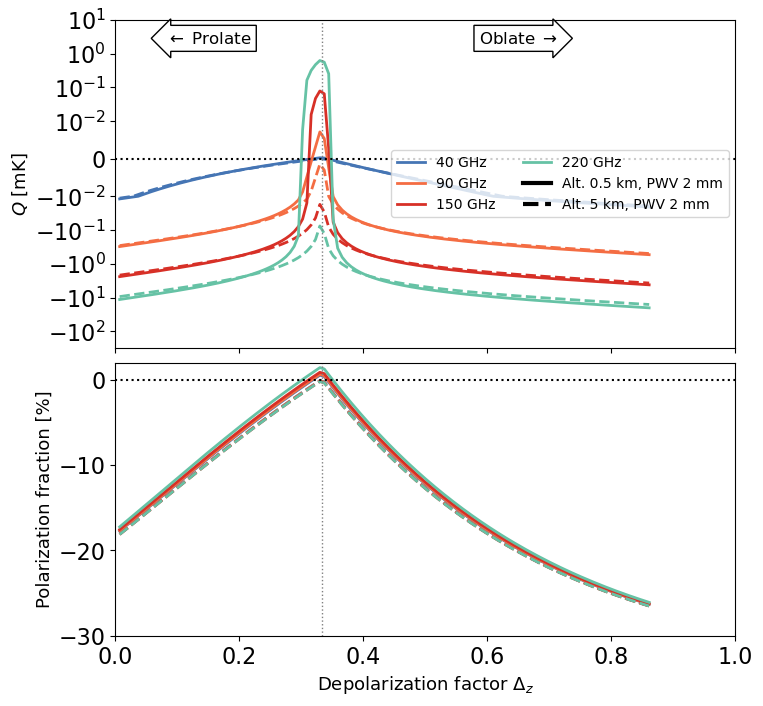

In [9]:
# =========================================================
# 4. REPRODUCE FIGURE 3 (CLASS Paper)
# =========================================================
# Convert signals to milliKelvin
Q_out_1_mK = Q_out_1 * 1000.0
Q_out_2_mK = Q_out_2 * 1000.0

# Calculate Polarization Fraction (%)
Pol_frac_1 = (Q_out_1 / I_out_1) * 100.0
Pol_frac_2 = (Q_out_2 / I_out_2) * 100.0

# Setup the dual-panel figure
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8), sharex=True, gridspec_kw={'height_ratios': [1.2, 1]})
plt.subplots_adjust(hspace=0.05)

# CLASS Frequencies: 40, 90, 150, 220 GHz
colors = ['#4575b4', '#f46d43', '#d73027', '#66c2a5'] 
freq_labels = ['40 GHz', '90 GHz', '150 GHz', '220 GHz']

for f_idx in range(N_freq):
    # --- Top Panel: Stokes Q [mK] ---
    ax1.plot(delta_z_array, Q_out_1_mK[f_idx, :], color=colors[f_idx], linestyle='-', linewidth=2, label=f"{freq_labels[f_idx]}")
    ax1.plot(delta_z_array, Q_out_2_mK[f_idx, :], color=colors[f_idx], linestyle='--', linewidth=2)
    
    # --- Bottom Panel: Polarization Fraction [%] ---
    # The paper plots this as absolute value, or relies on the sign. 
    # The paper shows negative fractions for oblate and prolate, peaking at 0 for spheres.
    ax2.plot(delta_z_array, Pol_frac_1[f_idx, :], color=colors[f_idx], linestyle='-', linewidth=2)
    ax2.plot(delta_z_array, Pol_frac_2[f_idx, :], color=colors[f_idx], linestyle='--', linewidth=2)

# --- Formatting Top Panel (Q) ---
ax1.axhline(0, color='black', linestyle=':', linewidth=1.5)
ax1.axvline(1/3, color='gray', linestyle=':', linewidth=1.0)
ax1.set_yscale('symlog', linthresh=0.01)
ax1.set_ylim(-300, 10)
ax1.set_ylabel(r'$Q$ [mK]', fontsize=13)

# Add custom annotations mimicking the paper
ax1.text(0.15, 2, r'$\leftarrow$ Prolate', fontsize=12, ha='center', bbox=dict(facecolor='white', edgecolor='black', boxstyle='larrow,pad=0.3'))
ax1.text(0.65, 2, r'Oblate $\rightarrow$', fontsize=12, ha='center', bbox=dict(facecolor='white', edgecolor='black', boxstyle='rarrow,pad=0.3'))

# Add dummy lines for altitude legend
line_alt1, = ax1.plot([], [], color='black', linestyle='-', label='Alt. 0.5 km, PWV 2 mm')
line_alt2, = ax1.plot([], [], color='black', linestyle='--', label='Alt. 5 km, PWV 2 mm')
ax1.legend(loc='right', fontsize=10, ncol=2)

# --- Formatting Bottom Panel (Polarization Fraction) ---
ax2.axhline(0, color='black', linestyle=':', linewidth=1.5)
ax2.axvline(1/3, color='gray', linestyle=':', linewidth=1.0)
ax2.set_ylim(-30, 2)
ax2.set_xlim(0.0, 1.0)
ax2.set_xlabel(r'Depolarization factor $\Delta_z$', fontsize=13)
ax2.set_ylabel(r'Polarization fraction [%]', fontsize=13)

plt.show()

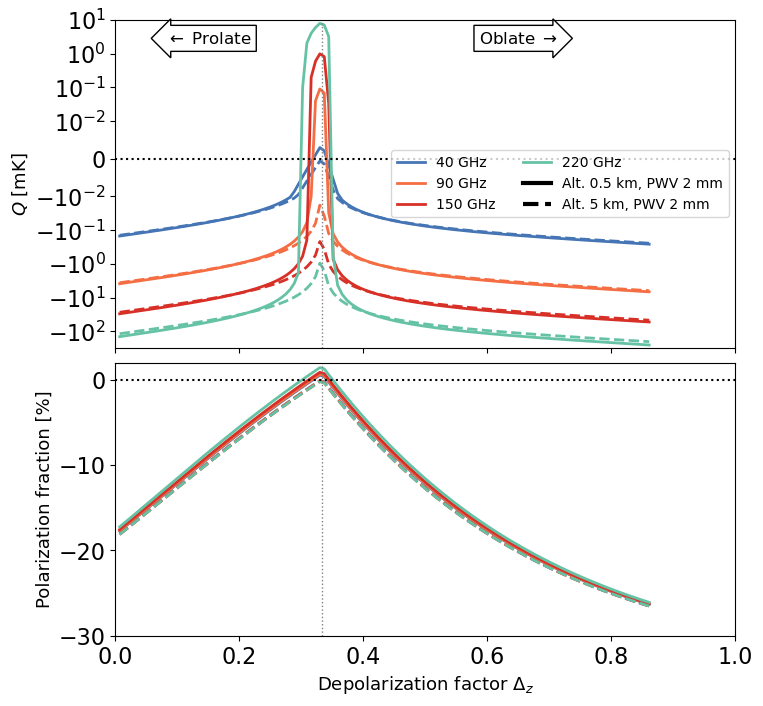

In [10]:
# =========================================================
# 4. REPRODUCE FIGURE 3 (CLASS Paper)
# =========================================================
# Convert signals to milliKelvin
Q_out_1_mK = Q_out_1 * 1000.0 * 4*np.pi # to compare to the CLASS paper (might have an error in the paper?)
Q_out_2_mK = Q_out_2 * 1000.0 * 4*np.pi # to compare to the CLASS paper (might have an error in the paper?)

# Calculate Polarization Fraction (%)
Pol_frac_1 = (Q_out_1 / I_out_1) * 100.0
Pol_frac_2 = (Q_out_2 / I_out_2) * 100.0

# Setup the dual-panel figure
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8), sharex=True, gridspec_kw={'height_ratios': [1.2, 1]})
plt.subplots_adjust(hspace=0.05)

# CLASS Frequencies: 40, 90, 150, 220 GHz
colors = ['#4575b4', '#f46d43', '#d73027', '#66c2a5'] 
freq_labels = ['40 GHz', '90 GHz', '150 GHz', '220 GHz']

for f_idx in range(N_freq):
    # --- Top Panel: Stokes Q [mK] ---
    ax1.plot(delta_z_array, Q_out_1_mK[f_idx, :], color=colors[f_idx], linestyle='-', linewidth=2, label=f"{freq_labels[f_idx]}")
    ax1.plot(delta_z_array, Q_out_2_mK[f_idx, :], color=colors[f_idx], linestyle='--', linewidth=2)
    
    # --- Bottom Panel: Polarization Fraction [%] ---
    # The paper plots this as absolute value, or relies on the sign. 
    # The paper shows negative fractions for oblate and prolate, peaking at 0 for spheres.
    ax2.plot(delta_z_array, Pol_frac_1[f_idx, :], color=colors[f_idx], linestyle='-', linewidth=2)
    ax2.plot(delta_z_array, Pol_frac_2[f_idx, :], color=colors[f_idx], linestyle='--', linewidth=2)

# --- Formatting Top Panel (Q) ---
ax1.axhline(0, color='black', linestyle=':', linewidth=1.5)
ax1.axvline(1/3, color='gray', linestyle=':', linewidth=1.0)
ax1.set_yscale('symlog', linthresh=0.01)
ax1.set_ylim(-300, 10)
ax1.set_ylabel(r'$Q$ [mK]', fontsize=13)

# Add custom annotations mimicking the paper
ax1.text(0.15, 2, r'$\leftarrow$ Prolate', fontsize=12, ha='center', bbox=dict(facecolor='white', edgecolor='black', boxstyle='larrow,pad=0.3'))
ax1.text(0.65, 2, r'Oblate $\rightarrow$', fontsize=12, ha='center', bbox=dict(facecolor='white', edgecolor='black', boxstyle='rarrow,pad=0.3'))

# Add dummy lines for altitude legend
line_alt1, = ax1.plot([], [], color='black', linestyle='-', label='Alt. 0.5 km, PWV 2 mm')
line_alt2, = ax1.plot([], [], color='black', linestyle='--', label='Alt. 5 km, PWV 2 mm')
ax1.legend(loc='right', fontsize=10, ncol=2)

# --- Formatting Bottom Panel (Polarization Fraction) ---
ax2.axhline(0, color='black', linestyle=':', linewidth=1.5)
ax2.axvline(1/3, color='gray', linestyle=':', linewidth=1.0)
ax2.set_ylim(-30, 2)
ax2.set_xlim(0.0, 1.0)
ax2.set_xlabel(r'Depolarization factor $\Delta_z$', fontsize=13)
ax2.set_ylabel(r'Polarization fraction [%]', fontsize=13)

plt.show()